# QG Framework — Global Analysis Notebook

Cross-course analysis of question quality across all evaluated courses.

**Sections**
1. Setup
2. Pipeline — build dataset + evaluate missing courses
3. Load all results
4. Dataset overview
5. Score analysis by aspect
6. Score analysis by dimension
7. Comparison: Field
8. Comparison: Level (Undergraduate vs Graduate)
9. Comparison: Source type (Assignment vs Exam)
10. Course leaderboard (heatmap)
11. Dimension correlations
12. Metric discriminability
13. Flagged questions analysis

## 1. Setup

In [4]:
import sys, json, subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

ROOT = Path('..')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR     = ROOT / 'data' / 'raw'
RESULTS_DIR = ROOT / 'data' / 'results'

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Dimensions to exclude (no metrics wired yet)
SKIP_DIMS = {
    'difficulty', 'discrimination', 'guessing_careless',
    'distractor_functioning', 'item_fit', 'dimensionality', 'reliability',
    'group_bias', 'measurement_invariance', 'content_sensitivity',
    'harmful_content_risk',
}

FIELD_COLORS = {
    'mathematics':          '#4C72B0',
    'computer_science':     '#DD8452',
    'physics':              '#55A868',
    'economics':            '#937860',
    'health_sciences':      '#C44E52',
    'biomedical_engineering': '#8172B2',
    'biology':              '#64B5CD',
    'chemistry':            '#AAAAAA',
    'unknown':              '#DDDDDD',
}
LEVEL_COLORS = {'undergraduate': '#4C72B0', 'graduate': '#C44E52'}
SOURCE_COLORS = {'assignment': '#4C72B0', 'exam': '#DD8452'}

## 2. Pipeline

### 2a. Build dataset (extract → align → flatten)
Fast — only processes courses that don't have aligned records yet.

### 2b. Evaluate missing courses
Slow (~60–90 min per course). Only runs for courses without a `results/*.jsonl` file.
Run **2a first**, then decide which courses to evaluate in **2b**.

In [5]:
# ── 2a. Pipeline only (fast) ─────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, str(ROOT / 'scripts' / 'run_all.py'),
     '--no-eval', '--log-level', 'INFO'],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])


STDERR: /Users/omaramraninejjar/opt/anaconda3/bin/python: can't open file '/Users/omaramraninejjar/Research/AI Edu/QG/framework/../scripts/run_all.py': [Errno 2] No such file or directory



In [6]:
# ── 2b. Evaluate missing courses (slow — run deliberately) ───────────────
# Shows which courses still need evaluation, then runs them.
# Comment out the subprocess call if you want to review first.

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
done    = {p.stem.replace('_results','') for p in RESULTS_DIR.glob('*_results.jsonl')}
all_crs = {p.parent.name for p in RAW_DIR.glob('*/course_meta.json')}
pending = sorted(all_crs - done)

print(f'Already evaluated : {sorted(done)}')
print(f'Pending evaluation: {pending}')

if pending:
    print(f'\nStarting evaluation for: {pending}')
    print('This will take ~60–90 min per course. Progress is logged below.')
    result = subprocess.run(
        [sys.executable, str(ROOT / 'scripts' / 'run_all.py'),
         '--log-level', 'INFO'],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    print(result.stdout[-5000:] if len(result.stdout) > 5000 else result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
else:
    print('All courses already evaluated — nothing to do.')

Already evaluated : ['14.06', '14.382', '18.100A', '6.042J', '6.046J', '6.830', '8.04', '8.321', 'HST.151', 'HST.542J']
Pending evaluation: []
All courses already evaluated — nothing to do.


## 3. Load all results

Reads every `data/results/{course_id}_results.jsonl` and enriches each row
with `field`, `level`, `subject` from the corresponding `course_meta.json`.

In [7]:
def load_course_meta(course_id):
    p = RAW_DIR / course_id / 'course_meta.json'
    return json.loads(p.read_text()) if p.exists() else {}

rows = []
load_errors = []
result_files = sorted(RESULTS_DIR.glob('*_results.jsonl'))  # list, not generator

for rpath in result_files:
    course_id = rpath.stem.replace('_results', '')
    meta = load_course_meta(course_id)
    try:
        for line in rpath.open(encoding='utf-8'):
            row = json.loads(line)
            # Normalise score format (float → dict for old-format files)
            for asp, dims in row['scores'].items():
                for dim, metrics in dims.items():
                    for m, v in list(metrics.items()):
                        if isinstance(v, (int, float)):
                            metrics[m] = {'score': v, 'flagged': False, 'rationale': ''}
            row['field']   = meta.get('field', 'unknown')
            row['level']   = meta.get('level', 'unknown')
            row['subject'] = meta.get('subject', course_id)
            rows.append(row)
    except Exception as exc:
        load_errors.append(f'{rpath.name}: {exc}')

if load_errors:
    print('LOAD ERRORS:')
    for e in load_errors: print(f'  {e}')

print(f'Loaded {len(rows)} question results from {len(result_files)} course(s)')

# ── Master flat DataFrame (one row per metric measurement) ───────────
flat_rows = []
flat_errors = []
for row in rows:
    for asp, dims in row['scores'].items():
        for dim, metrics in dims.items():
            if dim in SKIP_DIMS or not metrics:
                continue
            for m, v in metrics.items():
                try:
                    flat_rows.append({
                        'course_id':   row['course_id'],
                        'field':       row['field'],
                        'level':       row['level'],
                        'source_type': row.get('source_type'),
                        'question_id': row['question_id'],
                        'aspect':      asp,
                        'dimension':   dim,
                        'metric':      m,
                        'score':       v['score'],
                        'flagged':     v.get('flagged', v['score'] < 0.3),
                    })
                except Exception as exc:
                    flat_errors.append(f'{row["course_id"]}/{asp}/{dim}/{m}: {exc!r} (v={v!r})')

if flat_errors:
    print(f'{len(flat_errors)} flat-row errors (first 5):')
    for e in flat_errors[:5]: print(f'  {e}')

df = pd.DataFrame(flat_rows)
print(f'Master DataFrame: {len(df):,} metric measurements')
print(f'Courses : {sorted(df["course_id"].unique())}')
print(f'Fields  : {sorted(df["field"].unique())}')
print(f'Levels  : {sorted(df["level"].unique())}')
print(f'Source types: {sorted(df["source_type"].dropna().unique())}')
df[['course_id','field','level','source_type']].drop_duplicates().sort_values('field')

Loaded 482 question results from 10 course(s)
Master DataFrame: 34,222 metric measurements
Courses : ['14.06', '14.382', '18.100A', '6.042J', '6.046J', '6.830', '8.04', '8.321', 'HST.151', 'HST.542J']
Fields  : ['computer_science', 'economics', 'health_sciences', 'mathematics', 'physics']
Levels  : ['graduate', 'undergraduate']
Source types: ['assignment', 'exam']


,course_id,field,level,source_type
17821,6.046J,computer_science,undergraduate,exam
20164,6.830,computer_science,graduate,assignment
11857,6.046J,computer_science,undergraduate,assignment
0,14.06,economics,undergraduate,assignment
1775,14.382,economics,graduate,exam
1349,14.06,economics,undergraduate,exam
30743,HST.542J,health_sciences,undergraduate,assignment
27903,HST.151,health_sciences,graduate,assignment
27974,HST.151,health_sciences,graduate,exam
33512,HST.542J,health_sciences,undergraduate,exam


## 4. Dataset overview

In [8]:
# Questions per course + breakdown
course_meta_df = pd.DataFrame([
    {'course_id': r['course_id'], 'field': r['field'],
     'level': r['level'], 'source_type': r['source_type']}
    for r in rows
])
overview = (
    course_meta_df.groupby(['course_id','field','level','source_type'])
    .size().reset_index(name='n_questions')
    .sort_values(['field','level','course_id','source_type'])
)
overview

,course_id,field,level,source_type,n_questions
9,6.830,computer_science,graduate,assignment,21
7,6.046J,computer_science,undergraduate,assignment,84
8,6.046J,computer_science,undergraduate,exam,33
2,14.382,economics,graduate,exam,1
0,14.06,economics,undergraduate,assignment,19
1,14.06,economics,undergraduate,exam,6
14,HST.151,health_sciences,graduate,assignment,1
15,HST.151,health_sciences,graduate,exam,39
16,HST.542J,health_sciences,undergraduate,assignment,39
17,HST.542J,health_sciences,undergraduate,exam,10


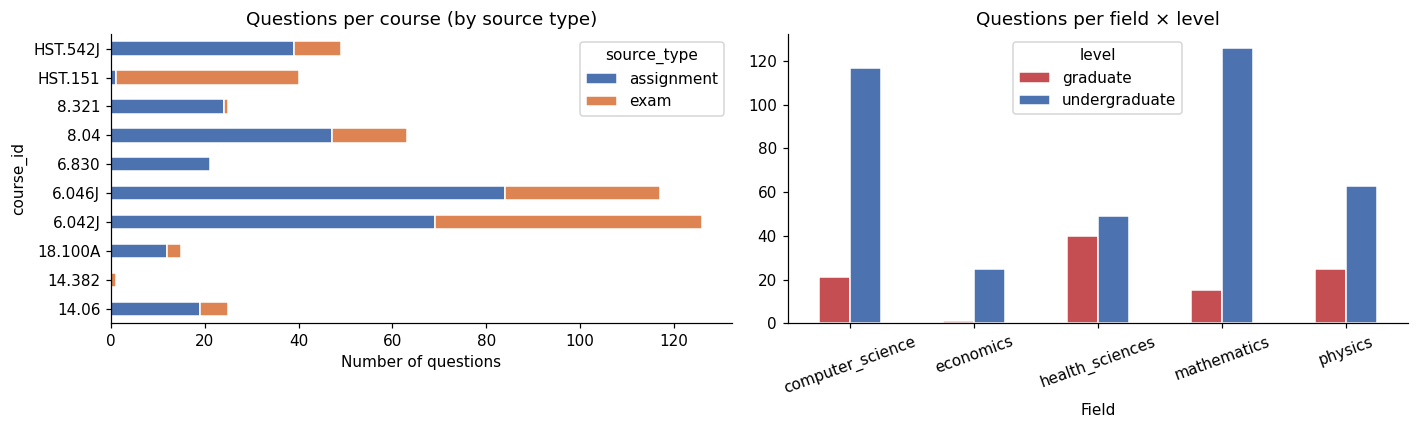

In [9]:
# Visual breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: questions per course, stacked by source_type
pivot_src = (
    course_meta_df.groupby(['course_id','source_type'])
    .size().unstack(fill_value=0)
)
colors_src = [SOURCE_COLORS.get(c,'grey') for c in pivot_src.columns]
pivot_src.plot(kind='barh', stacked=True, ax=axes[0], color=colors_src, edgecolor='white')
axes[0].set_xlabel('Number of questions')
axes[0].set_title('Questions per course (by source type)')

# Right: questions per field × level
pivot_fl = (
    course_meta_df.groupby(['field','level'])
    .size().unstack(fill_value=0)
)
colors_lvl = [LEVEL_COLORS.get(c,'grey') for c in pivot_fl.columns]
pivot_fl.plot(kind='bar', ax=axes[1], color=colors_lvl, edgecolor='white')
axes[1].set_xlabel('Field')
axes[1].set_title('Questions per field × level')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Score analysis by aspect

Aspect score = unweighted mean of all its dimension scores (which are themselves
means of metric scores). Psychometric is excluded — no student-response data yet.

In [10]:
from src.scorer import Scorer
scorer = Scorer()

# Build per-question aspect & dimension scores using Scorer
from src.models import (Question, EvaluationContext, EvaluationResult,
                        AspectResult, DimensionResult, MetricResult)

def rebuild_result(row):
    asp_scores = {}
    for asp, dims in row['scores'].items():
        dim_scores = {}
        for dim, metrics in dims.items():
            if not metrics:
                continue
            dim_scores[dim] = DimensionResult(
                dimension=dim,
                scores={m: MetricResult(metric_name=m, score=v['score'],
                                        flagged=v.get('flagged', False))
                        for m, v in metrics.items()}
            )
        asp_scores[asp] = AspectResult(aspect=asp, scores=dim_scores)
    return EvaluationResult(question_id=row['question_id'], scores=asp_scores)

score_rows = []
for row in rows:
    result = rebuild_result(row)
    for asp_name, asp_res in result.scores.items():
        if not asp_res.scores:
            continue
        asp_score = scorer.aggregate_aspect(asp_res)
        for dim_name, dim_res in asp_res.scores.items():
            if not dim_res.scores:
                continue
            score_rows.append({
                'course_id':   row['course_id'],
                'field':       row['field'],
                'level':       row['level'],
                'source_type': row['source_type'],
                'question_id': row['question_id'],
                'aspect':      asp_name,
                'dimension':   dim_name,
                'asp_score':   asp_score,
                'dim_score':   scorer.aggregate_dimension(dim_res),
            })

df_scores = pd.DataFrame(score_rows)

# Summary: mean aspect score per course
asp_summary = (
    df_scores.groupby(['course_id', 'field', 'level', 'aspect'])['asp_score']
    .mean().reset_index()
    .sort_values(['aspect','asp_score'], ascending=[True, False])
)
asp_pivot = asp_summary.pivot(index='course_id', columns='aspect', values='asp_score')
asp_pivot.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=1)

aspect,fairness_ethics,linguistic_structural,pedagogical
course_id,,,
14.06,0.747495,0.658061,0.386892
14.382,0.876506,0.664293,0.442129
18.100A,0.723710,0.653989,0.385983
6.042J,0.691619,0.637105,0.351149
6.046J,0.787488,0.611027,0.359504
6.830,0.627921,0.631564,0.383773
8.04,0.661870,0.638271,0.344165
8.321,0.601325,0.634876,0.366917
HST.151,0.882459,0.693779,0.373332


## 6. Score analysis by dimension

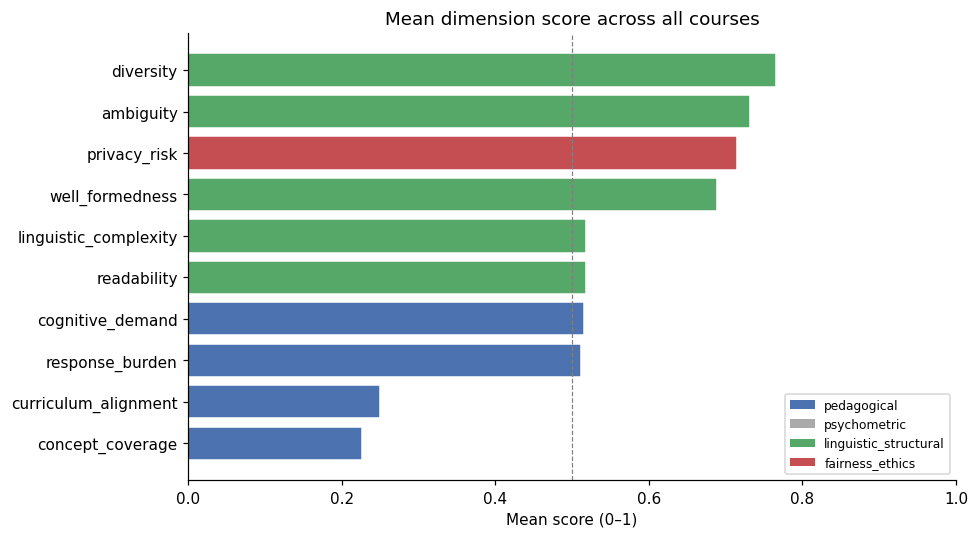

In [11]:
dim_summary = (
    df_scores.groupby(['course_id','field','level','aspect','dimension'])['dim_score']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
    .sort_values(['aspect','mean'], ascending=[True, False])
)

# Horizontal bar chart — mean dim score per dimension, colored by aspect
ASPECT_COLORS = {
    'pedagogical':           '#4C72B0',
    'psychometric':          '#AAAAAA',
    'linguistic_structural': '#55A868',
    'fairness_ethics':       '#C44E52',
}

agg = dim_summary.groupby(['aspect','dimension'])['mean'].mean().reset_index()
agg = agg.sort_values('mean')
colors = [ASPECT_COLORS.get(a,'grey') for a in agg['aspect']]

fig, ax = plt.subplots(figsize=(9, max(5, len(agg)*0.45)))
bars = ax.barh(agg['dimension'], agg['mean'], color=colors, edgecolor='white')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, label='0.5 threshold')
ax.set_xlim(0, 1)
ax.set_xlabel('Mean score (0–1)')
ax.set_title('Mean dimension score across all courses')
legend_patches = [Patch(facecolor=c, label=asp) for asp, c in ASPECT_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Comparison: Field

How does question quality differ across academic fields?
Expected differences:
- **Readability**: Physics/Chemistry questions shorter but notation-heavy → lower scores
- **Cognitive demand**: Graduate-level sciences likely higher Bloom levels
- **Well-formedness**: Math proofs use declarative style (no '?') → lower question_mark scores

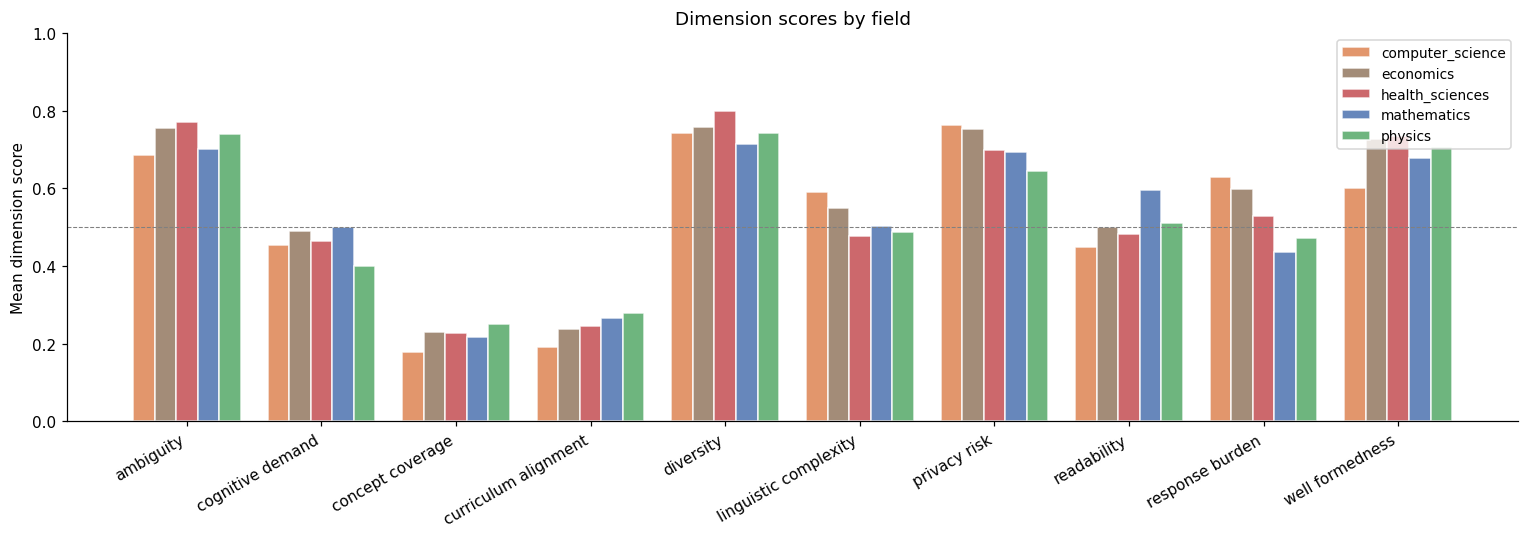

In [12]:
fields_available = df_scores['field'].nunique()
if fields_available < 2:
    print('Only one field in the dataset — add more courses to enable field comparison.')
    print(f'Current: {df_scores["field"].unique().tolist()}')
else:
    field_dim = (
        df_scores.groupby(['field','dimension'])['dim_score']
        .mean().reset_index()
    )
    dims = sorted(field_dim['dimension'].unique())
    fields = sorted(field_dim['field'].unique())
    x = np.arange(len(dims))
    w = 0.8 / len(fields)

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, field in enumerate(fields):
        sub = field_dim[field_dim['field'] == field].set_index('dimension')
        vals = [sub.loc[d, 'dim_score'] if d in sub.index else 0 for d in dims]
        ax.bar(x + i*w, vals, w, label=field,
               color=FIELD_COLORS.get(field,'grey'), edgecolor='white', alpha=0.85)
    ax.set_xticks(x + w*(len(fields)-1)/2)
    ax.set_xticklabels([d.replace('_',' ') for d in dims], rotation=30, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Mean dimension score')
    ax.set_title('Dimension scores by field')
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.7)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

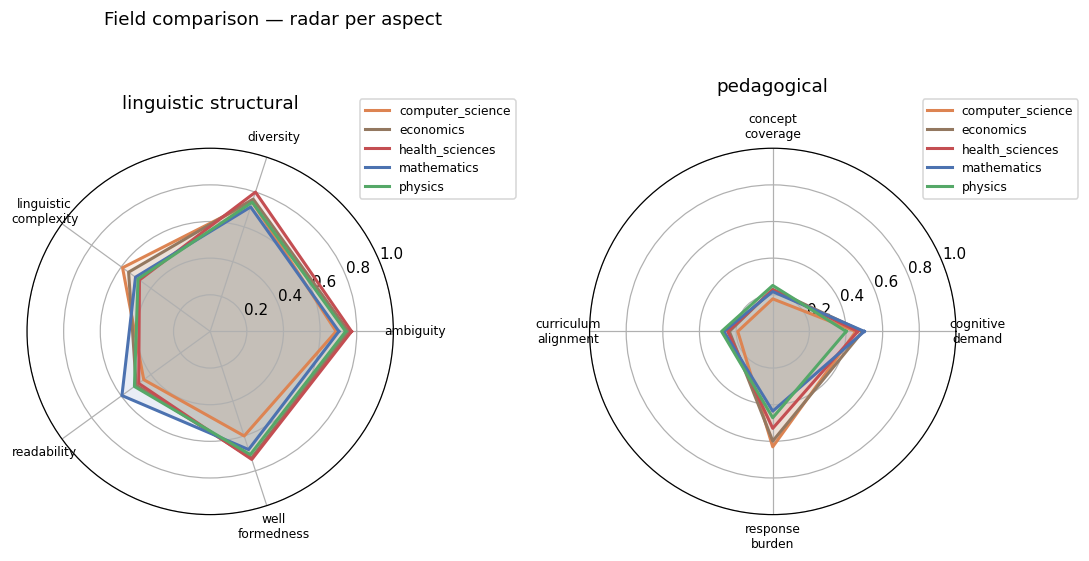

In [13]:
if fields_available >= 2:
    import numpy as np
    aspects = sorted(df_scores['aspect'].unique())
    fields  = sorted(df_scores['field'].unique())
    fig, axes = plt.subplots(1, len(aspects), figsize=(5*len(aspects), 5),
                              subplot_kw=dict(polar=True))
    if len(aspects) == 1: axes = [axes]
    for ax, asp in zip(axes, aspects):
        sub_asp = df_scores[df_scores['aspect'] == asp]
        dims_in = sorted(sub_asp['dimension'].unique())
        N = len(dims_in)
        if N < 3: ax.set_visible(False); continue
        angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
        angles += angles[:1]
        for field in fields:
            sub = sub_asp[sub_asp['field']==field]
            vals = [sub[sub['dimension']==d]['dim_score'].mean() for d in dims_in]
            vals += vals[:1]
            c = FIELD_COLORS.get(field,'grey')
            ax.plot(angles, vals, color=c, linewidth=2, label=field)
            ax.fill(angles, vals, color=c, alpha=0.12)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([d.replace('_','\n') for d in dims_in], size=8)
        ax.set_ylim(0,1); ax.set_title(asp.replace('_',' '), pad=14)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=8)
    fig.suptitle('Field comparison — radar per aspect', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Comparison: Level (Undergraduate vs Graduate)

Hypothesis: Graduate questions should score higher on **cognitive demand** and
lower on **readability** (denser notation), while **well-formedness** and
**fairness** should be similar across levels.

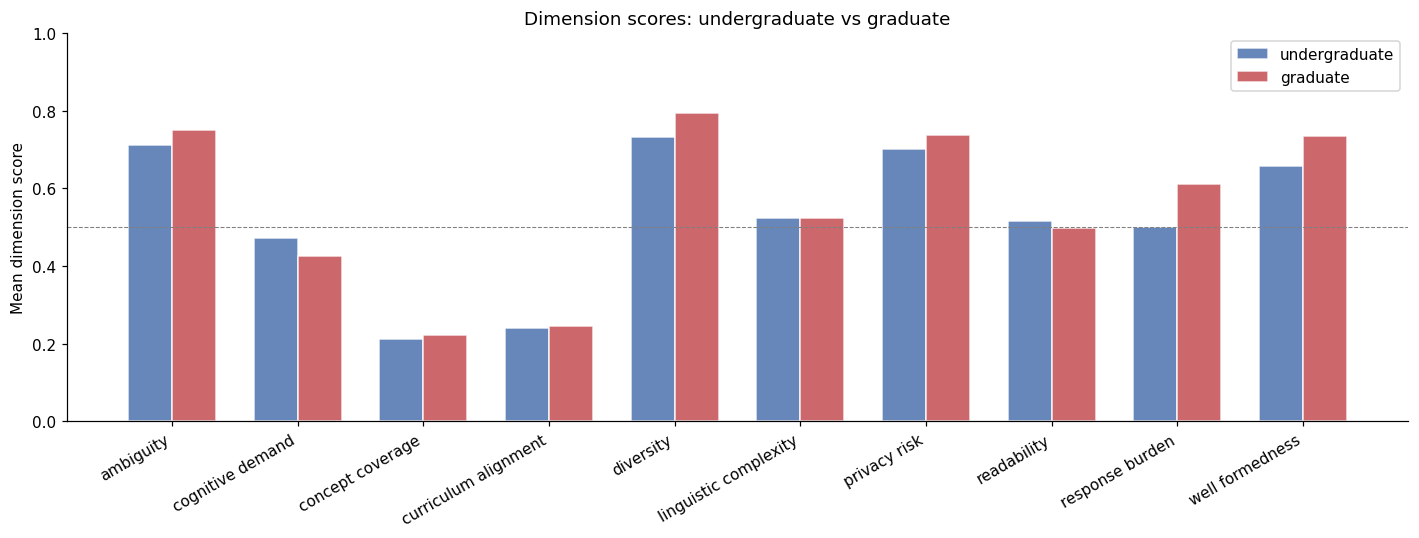


Mann-Whitney U test (undergraduate vs graduate) per dimension:
Dimension                          U-stat    p-value    significant
--------------------------------------------------------------------
ambiguity                         14088.5     0.0000       ✓ p<0.05
cognitive_demand                  21711.0     0.0594               
concept_coverage                  17279.0     0.0926               
curriculum_alignment              21667.0     0.0672               
diversity                         10899.0     0.0000       ✓ p<0.05
linguistic_complexity             18811.0     0.6490               
privacy_risk                      18859.0     0.6724               
readability                       21668.0     0.0670               
response_burden                   14656.5     0.0002       ✓ p<0.05
well_formedness                   11705.0     0.0000       ✓ p<0.05


In [14]:
levels_available = df_scores['level'].nunique()
if levels_available < 2:
    print('Only one level in the dataset — add graduate-level courses to enable comparison.')
    print(f'Current: {df_scores["level"].unique().tolist()}')
else:
    level_dim = (
        df_scores.groupby(['level','dimension'])['dim_score']
        .mean().reset_index()
    )
    dims = sorted(level_dim['dimension'].unique())
    x = np.arange(len(dims))
    w = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    for i, lvl in enumerate(['undergraduate', 'graduate']):
        sub = level_dim[level_dim['level']==lvl].set_index('dimension')
        vals = [sub.loc[d,'dim_score'] if d in sub.index else 0 for d in dims]
        ax.bar(x + i*w - w/2, vals, w, label=lvl,
               color=LEVEL_COLORS[lvl], edgecolor='white', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace('_',' ') for d in dims], rotation=30, ha='right')
    ax.set_ylim(0,1); ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.7)
    ax.set_ylabel('Mean dimension score')
    ax.set_title('Dimension scores: undergraduate vs graduate')
    ax.legend(); plt.tight_layout(); plt.show()

    # Statistical test
    try:
        from scipy import stats
        print('\nMann-Whitney U test (undergraduate vs graduate) per dimension:')
        print(f'{"Dimension":<30} {"U-stat":>10} {"p-value":>10} {"significant":>14}')
        print('-' * 68)
        for dim in sorted(df_scores['dimension'].unique()):
            ug = df_scores[(df_scores['level']=='undergraduate') & (df_scores['dimension']==dim)]['dim_score']
            gr = df_scores[(df_scores['level']=='graduate')     & (df_scores['dimension']==dim)]['dim_score']
            if len(ug) > 0 and len(gr) > 0:
                u, p = stats.mannwhitneyu(ug, gr, alternative='two-sided')
                sig = '✓ p<0.05' if p < 0.05 else ''
                print(f'{dim:<30} {u:>10.1f} {p:>10.4f} {sig:>14}')
    except ImportError:
        print('scipy not installed — skipping statistical tests')

## 9. Comparison: Source type (Assignment vs Exam)

Exams are typically higher-stakes and more strictly reviewed — we expect
better **well-formedness** and potentially higher **cognitive demand** in exams.

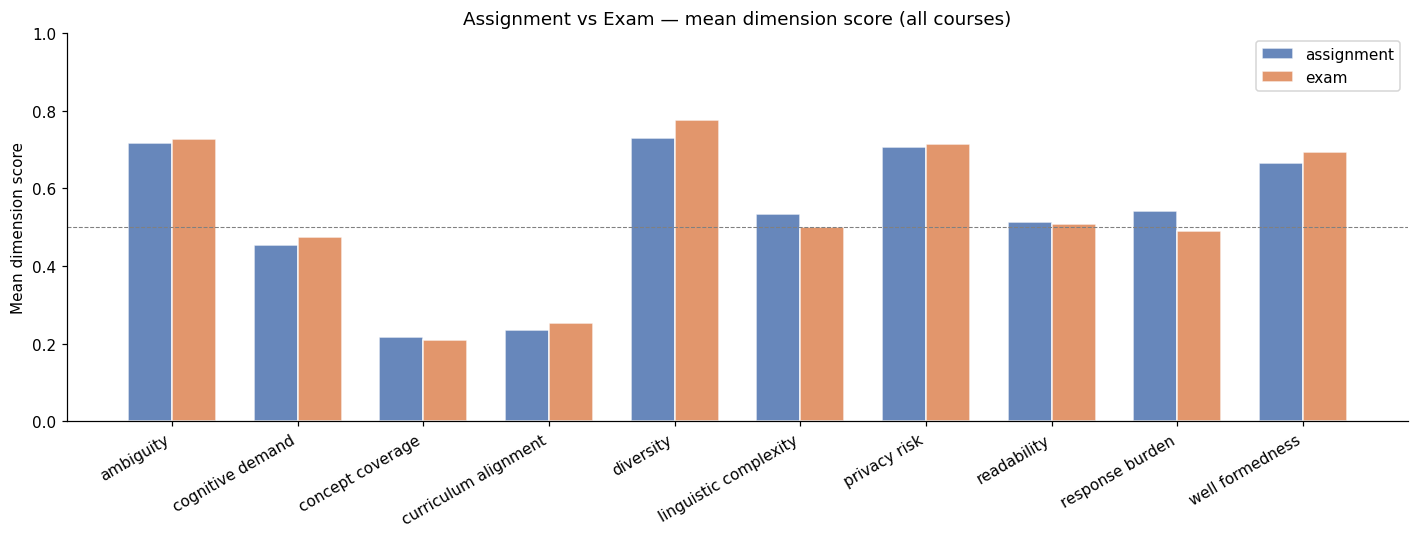

In [15]:
source_types_available = df_scores['source_type'].nunique()
if source_types_available < 2:
    print(f'Only one source type: {df_scores["source_type"].unique().tolist()}')
else:
    st_dim = (
        df_scores.groupby(['source_type','dimension'])['dim_score']
        .mean().reset_index()
    )
    dims = sorted(st_dim['dimension'].unique())
    x = np.arange(len(dims))
    w = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    for i, st in enumerate(['assignment','exam']):
        sub = st_dim[st_dim['source_type']==st].set_index('dimension')
        vals = [sub.loc[d,'dim_score'] if d in sub.index else 0 for d in dims]
        ax.bar(x + i*w - w/2, vals, w, label=st,
               color=SOURCE_COLORS.get(st,'grey'), edgecolor='white', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace('_',' ') for d in dims], rotation=30, ha='right')
    ax.set_ylim(0,1); ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.7)
    ax.set_ylabel('Mean dimension score')
    ax.set_title('Assignment vs Exam — mean dimension score (all courses)')
    ax.legend(); plt.tight_layout(); plt.show()

    # Diff table
    pivot_st = st_dim.pivot(index='dimension', columns='source_type', values='dim_score')
    pivot_st['diff (exam−assign)'] = pivot_st.get('exam',0) - pivot_st.get('assignment',0)
    pivot_st.sort_values('diff (exam−assign)', ascending=False).style.background_gradient(
        subset=['diff (exam−assign)'], cmap='RdYlGn', vmin=-0.3, vmax=0.3)

## 10. Course leaderboard (heatmap)

Each cell = mean dimension score for that course. Rows sorted by overall mean.
Colour: green = strong, red = weak.

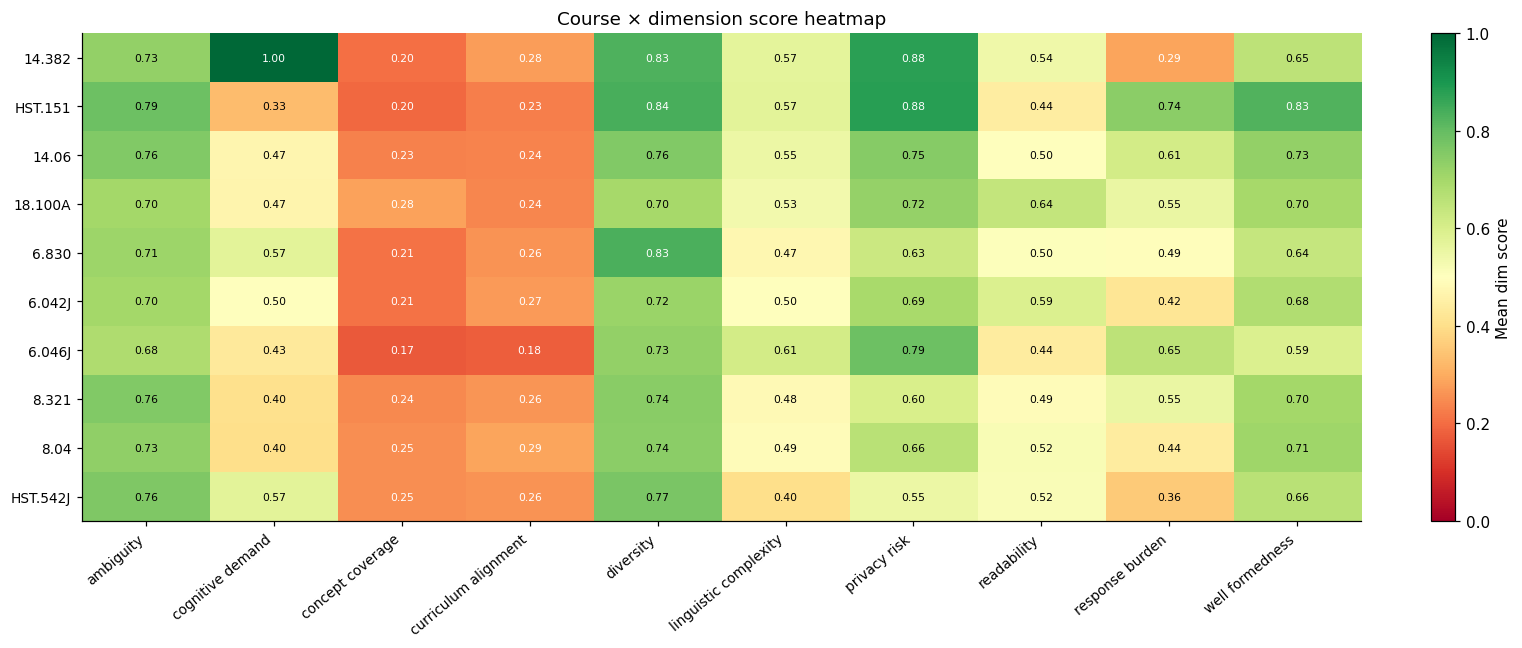

dimension,ambiguity,cognitive_demand,concept_coverage,curriculum_alignment,diversity,linguistic_complexity,privacy_risk,readability,response_burden,well_formedness,OVERALL
course_id,,,,,,,,,,,
14.382,0.727982,1.000000,0.203760,0.276631,0.830326,0.569101,0.876506,0.540984,0.288125,0.653069,0.596648
HST.151,0.788100,0.331250,0.195180,0.227916,0.838980,0.573636,0.882459,0.441925,0.738984,0.826254,0.584468
14.06,0.756065,0.470794,0.230632,0.235316,0.756630,0.549712,0.747495,0.497982,0.610825,0.729913,0.558536
18.100A,0.702337,0.466667,0.283196,0.239443,0.695796,0.534167,0.723710,0.640866,0.554625,0.696777,0.553758
6.830,0.711060,0.573321,0.210771,0.258322,0.832326,0.472685,0.627921,0.504717,0.492679,0.637031,0.532083
6.042J,0.702496,0.503586,0.209542,0.270537,0.716687,0.500320,0.691619,0.590151,0.420933,0.675870,0.528174
6.046J,0.682957,0.432539,0.171833,0.178978,0.727772,0.612745,0.787488,0.438162,0.654663,0.593500,0.528064
8.321,0.757632,0.404444,0.244538,0.264234,0.743963,0.480846,0.601325,0.490812,0.554450,0.701127,0.524337
8.04,0.732090,0.399471,0.253547,0.285320,0.740689,0.489542,0.661870,0.519381,0.438323,0.709651,0.522988


In [16]:
heatmap_data = (
    df_scores.groupby(['course_id','dimension'])['dim_score']
    .mean().unstack('dimension')
)
# Sort courses by overall mean (descending)
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values(ascending=False).index
]

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(max(14, len(heatmap_data.columns)*0.9),
                                 max(4, len(heatmap_data)*0.6)))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([c.replace('_',' ') for c in heatmap_data.columns],
                    rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if 0.3 < val < 0.8 else 'white')
plt.colorbar(im, ax=ax, label='Mean dim score', fraction=0.03)
ax.set_title('Course × dimension score heatmap')
plt.tight_layout()
plt.show()

# Numeric table with overall rank
heatmap_data['OVERALL'] = heatmap_data.mean(axis=1)
heatmap_data.sort_values('OVERALL', ascending=False).style.background_gradient(
    cmap='RdYlGn', vmin=0, vmax=1)

## 11. Dimension correlations

Do dimensions that score high together tend to cluster? This helps identify
redundant dimensions and potential factor structure in the framework.

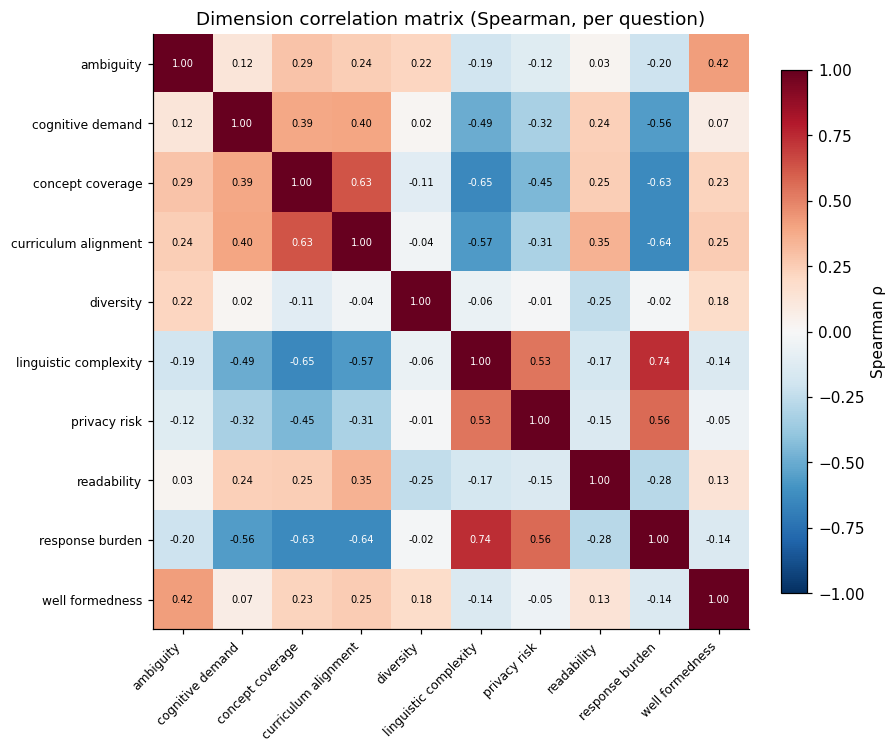

In [17]:
dim_wide = (
    df_scores.groupby(['question_id','dimension'])['dim_score']
    .mean().unstack('dimension')
)
corr = dim_wide.corr(method='spearman')

fig, ax = plt.subplots(figsize=(max(8, len(corr)*0.8), max(7, len(corr)*0.7)))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
labels = [c.replace('_',' ') for c in corr.columns]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=6.5, color='white' if abs(corr.values[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Spearman ρ', fraction=0.04)
ax.set_title('Dimension correlation matrix (Spearman, per question)')
plt.tight_layout(); plt.show()

## 12. Metric discriminability

Which metrics vary most across questions/courses? High variance = more informative.
Low-variance metrics (always near 0 or always near 1) add little diagnostic value.

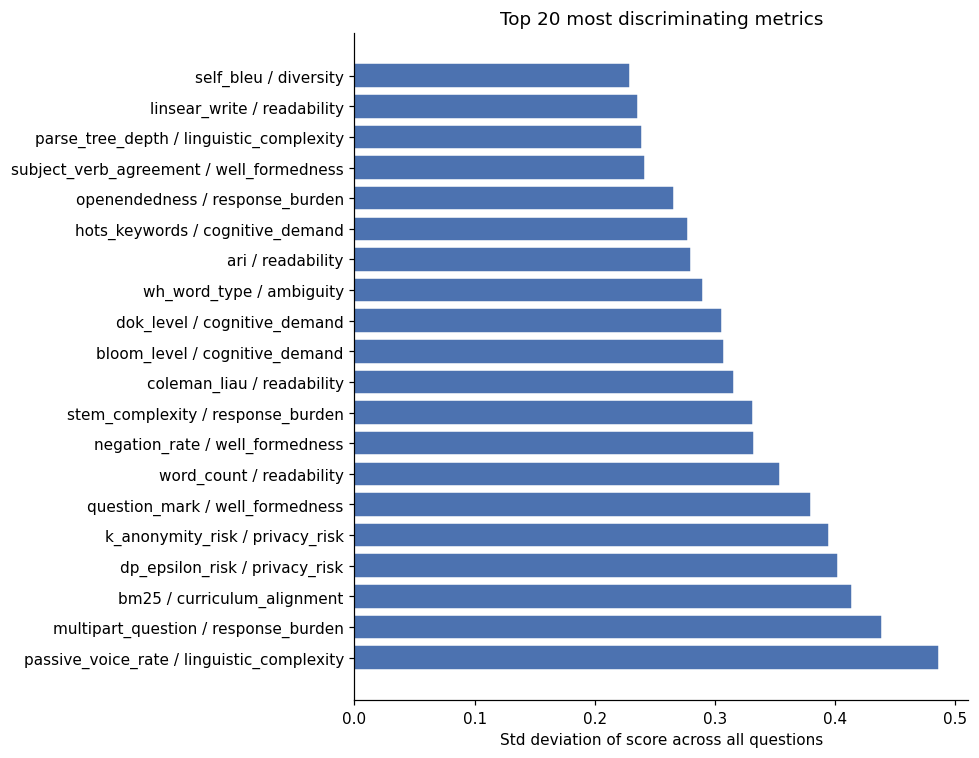


10 lowest-variance metrics (potentially redundant):
           dimension        metric  mean   std  range
    concept_coverage       rouge_l 0.108 0.055  0.324
curriculum_alignment       rouge_l 0.066 0.051  0.250
curriculum_alignment         tfidf 0.072 0.045  0.200
    concept_coverage     bertscore 0.732 0.042  0.245
curriculum_alignment     bertscore 0.694 0.034  0.163
           ambiguity pronoun_ratio 0.983 0.022  0.129
    concept_coverage          bleu 0.011 0.020  0.172
         readability    dale_chall 0.003 0.020  0.202
curriculum_alignment          bleu 0.005 0.006  0.046
    concept_coverage          bm25 0.000 0.000  0.000


In [18]:
metric_stats = (
    df.groupby(['dimension','metric'])['score']
    .agg(mean='mean', std='std', min='min', max='max')
    .reset_index()
)
metric_stats['range'] = metric_stats['max'] - metric_stats['min']
metric_stats = metric_stats.sort_values('std', ascending=False)

# Top 20 most discriminating metrics
top20 = metric_stats.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['metric'] + ' / ' + top20['dimension'],
        top20['std'], color='#4C72B0', edgecolor='white')
ax.set_xlabel('Std deviation of score across all questions')
ax.set_title('Top 20 most discriminating metrics')
plt.tight_layout(); plt.show()

print('\n10 lowest-variance metrics (potentially redundant):')
metric_stats.tail(10)[['dimension','metric','mean','std','range']].to_string(index=False)
print(metric_stats.tail(10)[['dimension','metric','mean','std','range']].to_string(index=False))

## 13. Flagged questions analysis

A metric is flagged if `score < 0.30` (fallback for older saved files) or `flagged=True`.
Flag rate = fraction of questions with at least one flagged metric in that dimension.

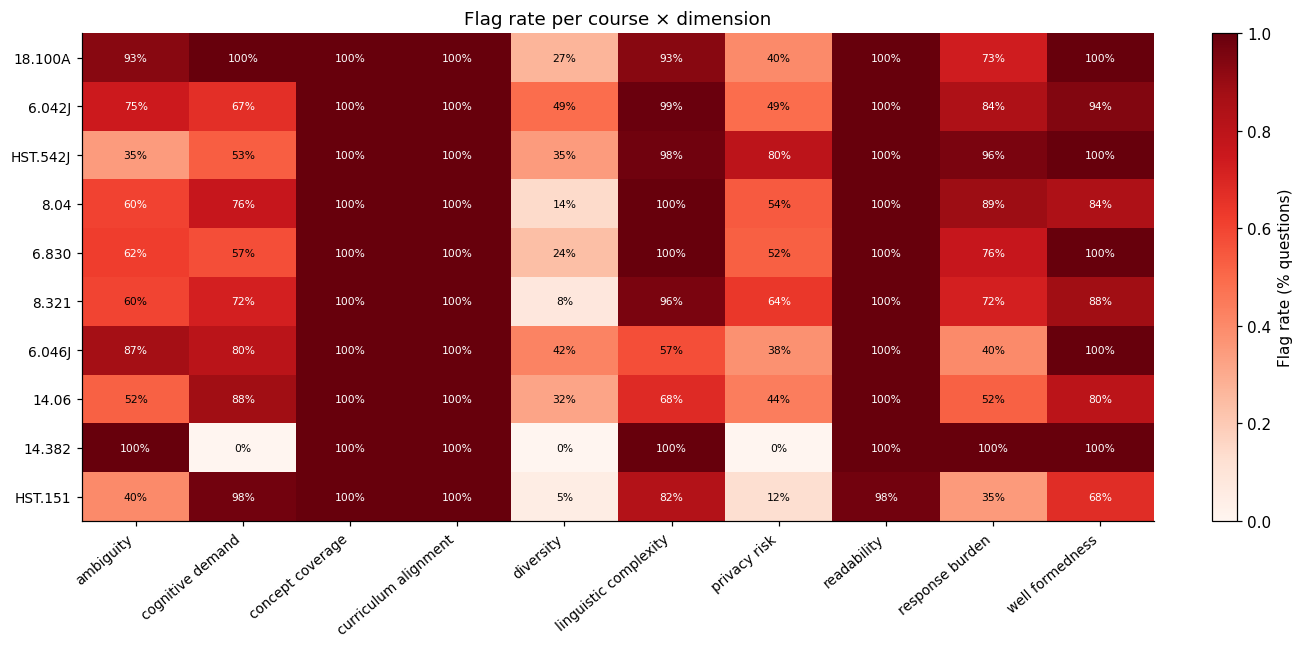


Overall flag rate per dimension:
  concept_coverage               100.0%  ██████████████████████████████
  curriculum_alignment           100.0%  ██████████████████████████████
  readability                    99.8%  █████████████████████████████
  well_formedness                91.4%  ███████████████████████████
  linguistic_complexity          89.4%  ██████████████████████████
  response_burden                71.8%  █████████████████████
  cognitive_demand               69.1%  ████████████████████
  ambiguity                      66.4%  ███████████████████
  privacy_risk                   43.3%  ████████████
  diversity                      23.6%  ███████


In [19]:
# Flag rate per course × dimension
flag_df = (
    df.groupby(['course_id','dimension','question_id'])['flagged']
    .any().reset_index()
)
flag_rate = (
    flag_df.groupby(['course_id','dimension'])['flagged']
    .mean().reset_index(name='flag_rate')
)

flag_pivot = flag_rate.pivot(index='course_id', columns='dimension', values='flag_rate').fillna(0)
flag_pivot = flag_pivot.loc[flag_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(max(12, len(flag_pivot.columns)*0.9),
                                 max(4, len(flag_pivot)*0.6)))
im = ax.imshow(flag_pivot.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(flag_pivot.columns)))
ax.set_xticklabels([c.replace('_',' ') for c in flag_pivot.columns],
                    rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(flag_pivot.index)))
ax.set_yticklabels(flag_pivot.index, fontsize=9)
for i in range(len(flag_pivot.index)):
    for j in range(len(flag_pivot.columns)):
        ax.text(j, i, f'{flag_pivot.values[i,j]:.0%}', ha='center', va='center',
                fontsize=7, color='white' if flag_pivot.values[i,j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Flag rate (% questions)', fraction=0.03)
ax.set_title('Flag rate per course × dimension')
plt.tight_layout(); plt.show()

# Overall flag rate per dimension (across all courses)
overall_flag = flag_rate.groupby('dimension')['flag_rate'].mean().sort_values(ascending=False)
print('\nOverall flag rate per dimension:')
for dim, rate in overall_flag.items():
    bar = '█' * int(rate * 30)
    print(f'  {dim:<30} {rate:.1%}  {bar}')

---
## 14. Summary Plot Groups

Three composite figures merging the key signals from earlier sections.
Each group is a single `plt.subplots(1, 2)` figure for direct side-by-side comparison.

- **Group 1** — Flag rate by metric family · Top discriminating metrics by σ
- **Group 2** — Mean dimension scores (aspect-coloured) · Spearman correlation (key cells highlighted)
- **Group 3** — Flag rate: LLMs vs metrics · Inter-LLM disagreement per dimension

### Group 1 — Flag rate by metric family  ·  Top discriminating metrics by σ

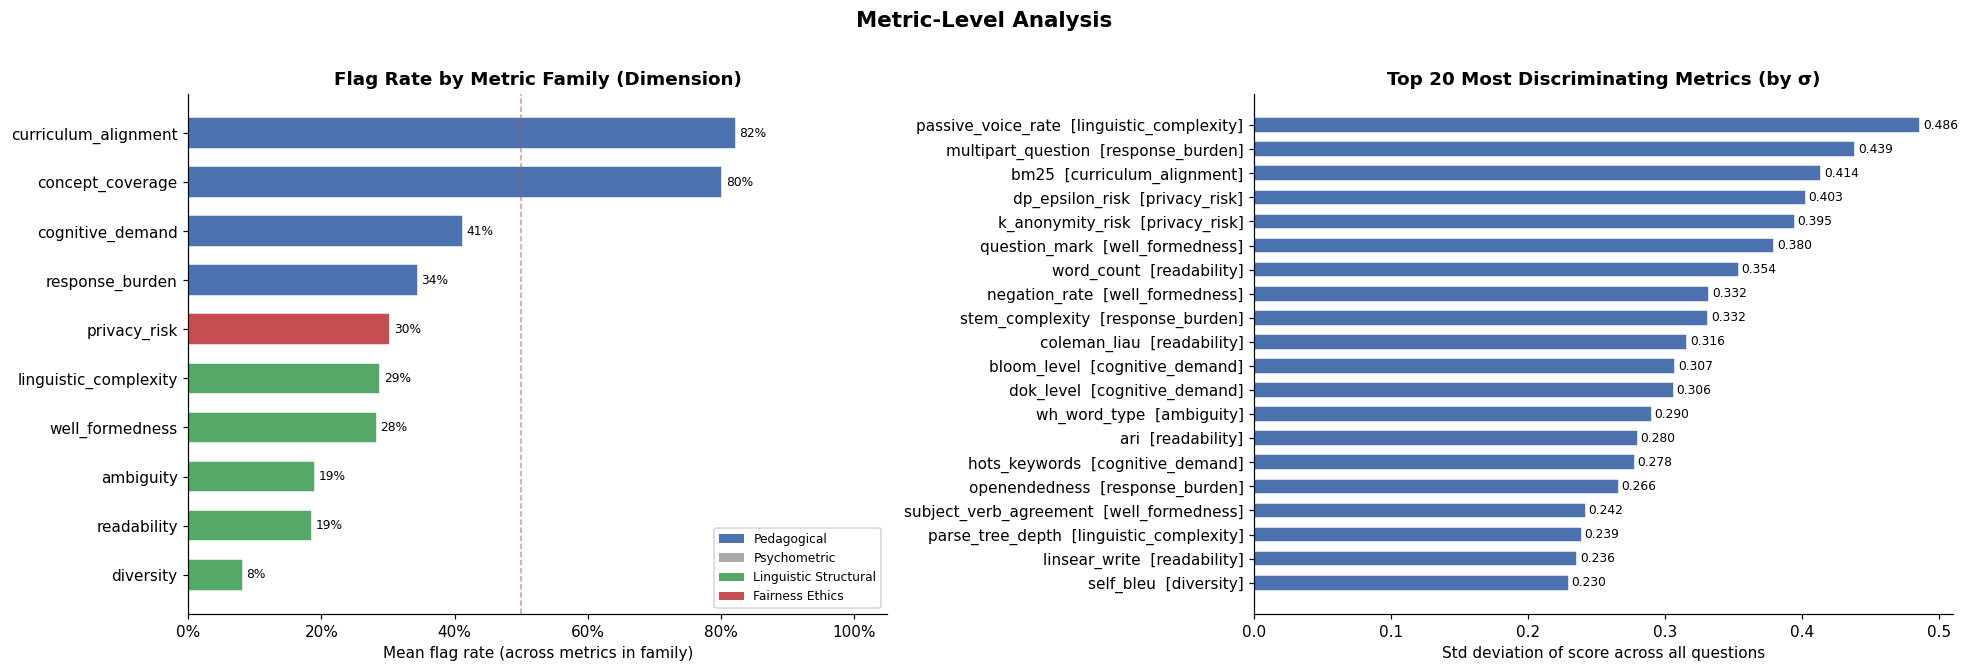

In [24]:
# ── pre-compute ──────────────────────────────────────────────────────────
metric_flag = (
    df.groupby(['dimension', 'metric'])['flagged']
    .mean().reset_index(name='flag_rate')
)
family_flag = (
    metric_flag.groupby('dimension')['flag_rate']
    .mean().reset_index(name='flag_rate')
    .sort_values('flag_rate')
)

top_n = 20
top_disc = metric_stats.head(top_n).copy()
top_disc['label'] = top_disc['metric'] + '  [' + top_disc['dimension'] + ']'

# ── figure ───────────────────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(18, max(6, len(family_flag) * 0.45)))

# LEFT — flag rate by metric family (dimension)
bar_colors = [ASPECT_COLORS.get(
    df.loc[df['dimension'] == d, 'aspect'].iloc[0], '#AAAAAA')
    for d in family_flag['dimension']]
bars = ax_l.barh(family_flag['dimension'], family_flag['flag_rate'],
                  color=bar_colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, family_flag['flag_rate']):
    ax_l.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
              f'{val:.0%}', va='center', fontsize=8)
ax_l.set_xlim(0, 1.05)
ax_l.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax_l.set_xlabel('Mean flag rate (across metrics in family)')
ax_l.set_title('Flag Rate by Metric Family (Dimension)', fontsize=12, fontweight='bold')
legend_els = [Patch(facecolor=c, label=a.replace('_', ' ').title())
              for a, c in ASPECT_COLORS.items()]
ax_l.legend(handles=legend_els, fontsize=8, loc='lower right')
ax_l.axvline(0.5, color='#C44E52', linestyle='--', lw=1, alpha=0.6)

# RIGHT — top discriminating metrics by std
ax_r.barh(top_disc['label'], top_disc['std'], color='#4C72B0',
           edgecolor='white', height=0.65)
for i, (_, row) in enumerate(top_disc.iterrows()):
    ax_r.text(row['std'] + 0.002, i, f'{row["std"]:.3f}', va='center', fontsize=8)
ax_r.set_xlabel('Std deviation of score across all questions')
ax_r.set_title(f'Top {top_n} Most Discriminating Metrics (by σ)', fontsize=12, fontweight='bold')
ax_r.invert_yaxis()

plt.suptitle('Metric-Level Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Group 2 — Mean dimension scores (aspect-coloured)  ·  Spearman correlation (key cells highlighted)

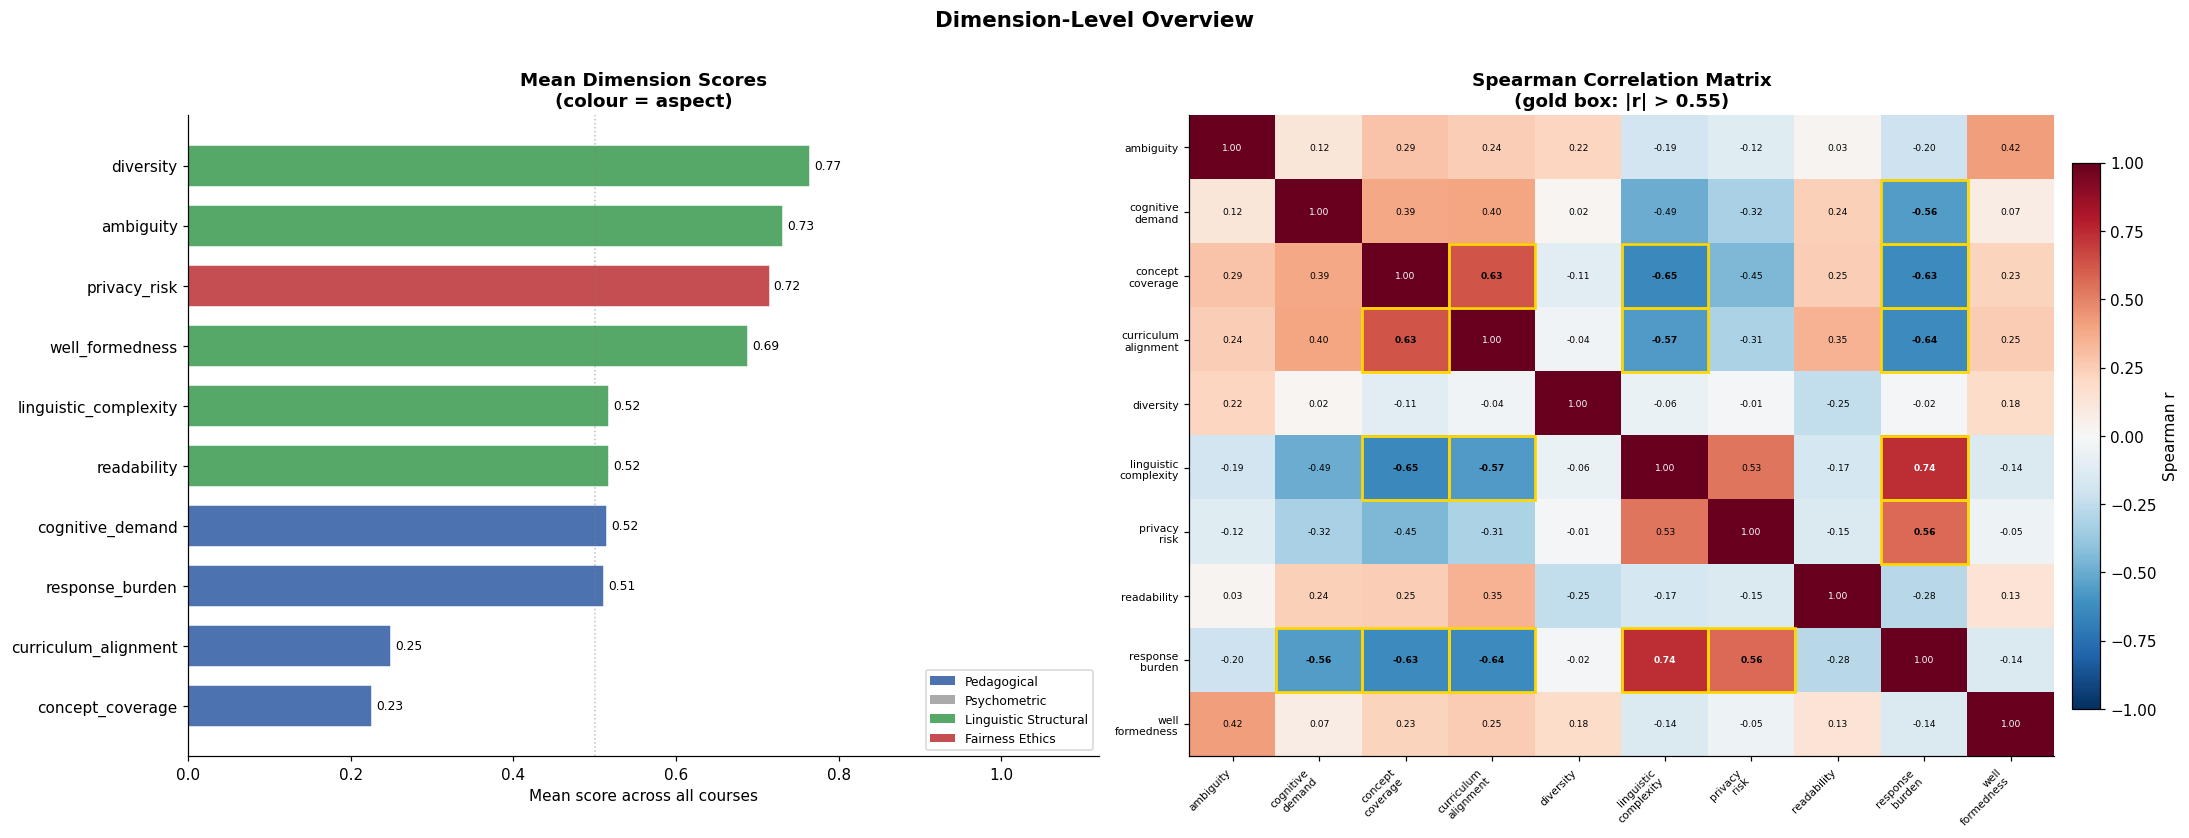

In [25]:
# ── pre-compute ──────────────────────────────────────────────────────────
agg2 = (
    dim_summary.groupby(['aspect', 'dimension'])['mean']
    .mean().reset_index()
    .sort_values('mean')
)
dim_colors2 = [ASPECT_COLORS.get(a, '#AAAAAA') for a in agg2['aspect']]

HIGHLIGHT_THRESH = 0.55   # |r| above this gets a box
n_dims = len(corr)

# ── figure ───────────────────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, max(7, n_dims * 0.75)))

# LEFT — mean dimension scores, colour-coded by aspect
bars = ax_l.barh(agg2['dimension'], agg2['mean'], color=dim_colors2,
                  edgecolor='white', height=0.7)
for bar, val in zip(bars, agg2['mean']):
    ax_l.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
              f'{val:.2f}', va='center', fontsize=8)
ax_l.set_xlim(0, 1.12)
ax_l.set_xlabel('Mean score across all courses')
ax_l.set_title('Mean Dimension Scores\n(colour = aspect)', fontsize=12, fontweight='bold')
ax_l.axvline(0.5, color='grey', linestyle=':', lw=1, alpha=0.5)
legend_els = [Patch(facecolor=c, label=a.replace('_', ' ').title())
              for a, c in ASPECT_COLORS.items()]
ax_l.legend(handles=legend_els, fontsize=8, loc='lower right')

# RIGHT — Spearman correlation with high-|r| cells highlighted
import matplotlib.colors as mcolors
im = ax_r.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
labels = [c.replace('_', '\n') for c in corr.columns]
ax_r.set_xticks(range(n_dims)); ax_r.set_yticks(range(n_dims))
ax_r.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax_r.set_yticklabels(labels, fontsize=7)
plt.colorbar(im, ax=ax_r, label='Spearman r', fraction=0.03, pad=0.02)

for i in range(n_dims):
    for j in range(n_dims):
        val = corr.values[i, j]
        text_color = 'white' if abs(val) > 0.65 else 'black'
        weight = 'bold' if (abs(val) > HIGHLIGHT_THRESH and i != j) else 'normal'
        ax_r.text(j, i, f'{val:.2f}', ha='center', va='center',
                  fontsize=6, color=text_color, fontweight=weight)
        # Box around key off-diagonal cells
        if abs(val) > HIGHLIGHT_THRESH and i != j:
            ax_r.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                fill=False, edgecolor='gold', linewidth=1.8
            ))

ax_r.set_title(f'Spearman Correlation Matrix\n(gold box: |r| > {HIGHLIGHT_THRESH})',
               fontsize=12, fontweight='bold')

plt.suptitle('Dimension-Level Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Group 3 — Flag rate: LLMs vs metrics  ·  Inter-LLM disagreement per dimension

In [22]:
# ── Load LLM eval data (6.042J only) ─────────────────────────────────────
LLM_DIR = RESULTS_DIR / 'llm_eval'
LLM_FILES_G3 = {
    'GPT-5.4':         LLM_DIR / '6.042J_gpt5.4_results.jsonl',
    'Claude 4.6 Opus': LLM_DIR / '6.042J_claude4.6opus_results.jsonl',
    'Gemini 3.1 Pro':  LLM_DIR / '6.042J_gemini3.1pro_results.jsonl',
}
LLM_COLORS_G3 = {
    'GPT-5.4':         '#4C72B0',
    'Claude 4.6 Opus': '#DD8452',
    'Gemini 3.1 Pro':  '#55A868',
}
G3_ASPECTS = {
    'pedagogical':           ['curriculum_alignment', 'cognitive_demand', 'concept_coverage', 'response_burden'],
    'psychometric':          ['difficulty', 'discrimination', 'guessing_careless', 'distractor_functioning',
                              'item_fit', 'dimensionality', 'reliability'],
    'linguistic_structural': ['readability', 'linguistic_complexity', 'ambiguity', 'well_formedness', 'diversity'],
    'fairness_ethics':       ['group_bias', 'measurement_invariance', 'content_sensitivity',
                              'harmful_content_risk', 'privacy_risk'],
}
G3_ALL_DIMS = [d for dims in G3_ASPECTS.values() for d in dims]

def _load_llm_g3(path):
    with open(path) as f:
        return json.loads('[' + f.read().strip() + ']')

def _extract_llm_g3(records):
    rows = []
    for r in records:
        row = {'question_id': r['question_id']}
        for asp, dims in G3_ASPECTS.items():
            for dim in dims:
                v = r.get('scores', {}).get(asp, {}).get(dim, {})
                row[dim] = v.get('score', float('nan')) if isinstance(v, dict) else float('nan')
        rows.append(row)
    return pd.DataFrame(rows).set_index('question_id')

llm_g3 = {name: _extract_llm_g3(_load_llm_g3(p)) for name, p in LLM_FILES_G3.items()}

# Metric-side flag rate per dimension (from master df, 6.042J only)
metric_flag_6042 = (
    df[df['course_id'] == '6.042J']
    .groupby('dimension')['flagged'].mean()
)

# Shared dimensions: present in BOTH metric df and at least one LLM
g3_shared = [
    d for d in G3_ALL_DIMS
    if d in metric_flag_6042.index and
    any(llm_g3[n][d].notna().any() for n in llm_g3)
]
print(f'Shared dims for Group 3 ({len(g3_shared)}): {g3_shared}')

Shared dims for Group 3 (10): ['curriculum_alignment', 'cognitive_demand', 'concept_coverage', 'response_burden', 'readability', 'linguistic_complexity', 'ambiguity', 'well_formedness', 'diversity', 'privacy_risk']


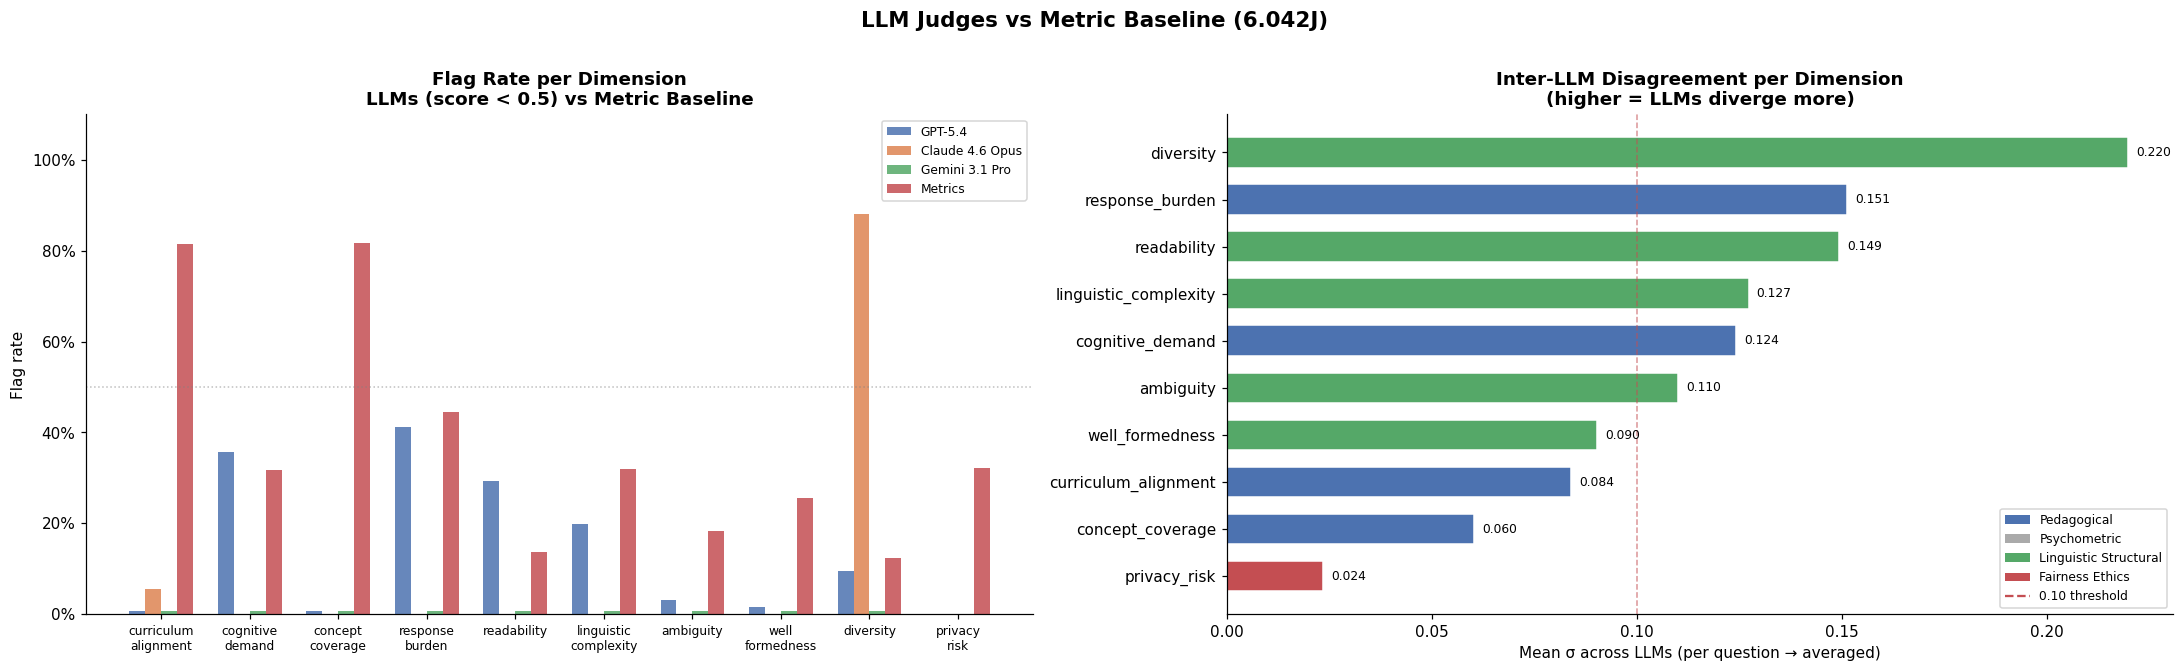

In [26]:
import numpy as np
FLAG_THR = 0.5

# ── LLM flag rate per dimension ───────────────────────────────────────────
llm_flag_g3 = pd.DataFrame(
    {name: (df_[g3_shared] < FLAG_THR).mean() for name, df_ in llm_g3.items()},
    index=g3_shared
)
# Add metric flag rate (already on 0-1 scale as fraction)
llm_flag_g3['Metrics'] = metric_flag_6042.reindex(g3_shared)

# ── Inter-LLM std per dimension ───────────────────────────────────────────
llm_names_g3 = list(llm_g3.keys())
all_q = llm_g3[llm_names_g3[0]].index
for df_ in llm_g3.values():
    all_q = all_q.intersection(df_.index)

stack = np.stack([llm_g3[n].loc[all_q, g3_shared].values for n in llm_names_g3], axis=0)
llm_std_g3 = pd.Series(
    np.nanstd(stack, axis=0).mean(axis=0),   # mean std across questions, per dim
    index=g3_shared
).sort_values(ascending=True)

# ── figure ───────────────────────────────────────────────────────────────
n_dims_g3 = len(g3_shared)
all_src = llm_names_g3 + ['Metrics']
src_colors_g3 = {**LLM_COLORS_G3, 'Metrics': '#C44E52'}

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(20, max(6, n_dims_g3 * 0.55)))

# LEFT — grouped bar: flag rate per dimension, LLMs vs Metrics
x = np.arange(n_dims_g3)
width = 0.18
for i, src in enumerate(all_src):
    vals = llm_flag_g3[src].values
    bars = ax_l.bar(x + i * width, np.nan_to_num(vals), width,
                    label=src, color=src_colors_g3[src], alpha=0.85)
ax_l.set_xticks(x + width * (len(all_src) - 1) / 2)
ax_l.set_xticklabels([d.replace('_', '\n') for d in g3_shared], fontsize=8, rotation=0)
ax_l.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax_l.set_ylim(0, 1.1)
ax_l.set_ylabel('Flag rate')
ax_l.set_title(f'Flag Rate per Dimension\nLLMs (score < {FLAG_THR}) vs Metric Baseline',
               fontsize=12, fontweight='bold')
ax_l.axhline(0.5, color='grey', linestyle=':', lw=1, alpha=0.5)
ax_l.legend(fontsize=8)

# RIGHT — horizontal bars: inter-LLM disagreement per dimension (mean σ)
bar_colors_r = [ASPECT_COLORS.get(
    next((asp for asp, dims in G3_ASPECTS.items() if d in dims), None), '#AAAAAA')
    for d in llm_std_g3.index]
ax_r.barh(llm_std_g3.index, llm_std_g3.values, color=bar_colors_r,
           edgecolor='white', height=0.65)
for i, (dim, val) in enumerate(llm_std_g3.items()):
    ax_r.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)
ax_r.axvline(0.1, color='#C44E52', linestyle='--', lw=1, alpha=0.6,
              label='0.10 threshold')
ax_r.set_xlabel('Mean σ across LLMs (per question → averaged)')
ax_r.set_title('Inter-LLM Disagreement per Dimension\n(higher = LLMs diverge more)',
               fontsize=12, fontweight='bold')
legend_els_r = [Patch(facecolor=c, label=a.replace('_', ' ').title())
                for a, c in ASPECT_COLORS.items()] + \
               [plt.Line2D([0], [0], color='#C44E52', linestyle='--', label='0.10 threshold')]
ax_r.legend(handles=legend_els_r, fontsize=8, loc='lower right')

plt.suptitle('LLM Judges vs Metric Baseline (6.042J)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()